In [54]:
## 3D Visualization for Time-Series

import numpy as np
import matplotlib.pyplot as plt
from dipy.io.image import load_nifti
import dicom2nifti
import nibabel as nib
from ipywidgets import interact
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import pydicom as dicom
import glob
import os


In [55]:
# Monteris CMAP code
colors_1=["white", "darkmagenta","blue","green","yellow","orange","red", "black"]
nodes_1 = [0.0, 0.04, 0.078, 0.14, 0.17, 0.23, 0.34, 1.0]
Monteris_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(nodes_1, colors_1)))

interactive(children=(IntSlider(value=20, description='i', max=40), Output()), _dom_classes=('widget-interact'…

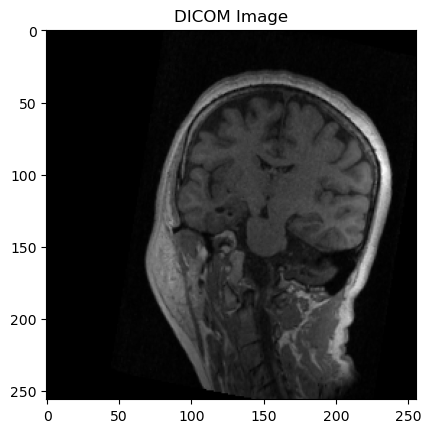

In [62]:
# INPUT FOLDER INFORMATION
root_folder = r"E:\\Documents\\MTLE" 
target_number = "0008"  # Replace "0001" with the specific number you want to isolate
target_suffix = "01"   # Replace "01" with the specific image folder you want to isolate

## EXAMPLE FORMAT - temperatureData is where all the dcm files are located
# "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\LP-0001-01-01-01\temperatureData"

# Create the pattern to match the target folders
folder_pattern = os.path.join(root_folder, "LP-{}*".format(target_number))
target_folders = glob.glob(folder_pattern)

# Iterate through the target folders (ie folders in L1-xxxx)
for target_folder in target_folders:
    # Create the pattern to match the temperatureData folder
    temperature_folder = os.path.join(target_folder, "LP-{}-01-01-{}\\temperatureData".format(target_number, target_suffix,target_number,target_suffix))
    target_folders = glob.glob(target_folder)

    # Create the pattern to match the S2.dcm files
    file_pattern = os.path.join(temperature_folder, "*.S2.dcm")

    # Use glob to find all matching files
    files = glob.glob(file_pattern)

    # Read all images in files (ie in ...//temperatureData)
    pixel_arrays = []
    for image_path in files:
        ds = dicom.dcmread(image_path)
        pixel_arrays.append(ds.pixel_array)

    array = np.stack(pixel_arrays, axis=-1)

    # Visualize Images as a Slider
    def show_slice_cmap(i):
        plt.imshow(array[:,:,i], cmap=Monteris_cmap, vmin=0, vmax=255)
        plt.title('Patient {} Image Slice at Index {}'.format(target_number,i))
        plt.show()

    # Show 3D slicer for colormap selection
    interact(show_slice_cmap, i=(0, array.shape[2]-1))

    #plot dicom file
    dicom_file = "E:\\Documents\\MTLE\\LP-{}\\LP-{}-01-01-{}\\anatomicalProbesEye\\fine.S2.dcm".format(target_number,target_number,target_suffix)
    # dicom_file = "E:\\Documents\\LP-0001-01-01-01\\LP-0001-01-01-01\\temperatureData\\080.S2.dcm"

    # Read the DICOM file
    ds = dicom.dcmread(dicom_file)

    # Display the DICOM image
    plt.imshow(ds.pixel_array, cmap='gray')
    plt.title('DICOM Image')
    plt.show()    
